In [1]:
import pandas as pd

In [2]:
df  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/unseen_test_results.csv')

In [3]:
new_model = df.sort_values(by=['similarity_score'], ascending=False)

In [4]:
df2  = pd.read_csv('/Users/drazenzack/Desktop/LLM_model/Model_Results/unseen_test_results_rag.csv')
rag_model = df2.sort_values(by=['similarity_score'], ascending=False)

In [5]:
# 2 * (number of matching characters)/ (total characters in both strings)
print('Rag Model Similarity:', rag_model['similarity_score'].mean())

Rag Model Similarity: 0.8702000000000001


In [6]:
# 2 * (number of matching characters)/ (total characters in both strings)
print('New Model Similarity:', new_model['similarity_score'].mean())

New Model Similarity: 0.8495


In [7]:
new_model.sort_values('similarity_score')

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error
58,59,Compute the mean and std of day_ahead_forecast...,df.groupby('region')['day_ahead_forecast'].agg...,df.groupby('region').day_ahead_forecast.mean()...,0.15,False,False,NaN
40,41,Return top 48 rows by solar_fcst_scaled.,"df.nlargest(48, 'solar_fcst_scaled')",df.loc[:47],0.21,False,False,NaN
56,57,Return top 29 rows by wind_fcst_raw.,"df.nlargest(29, 'wind_fcst_raw')",df.loc[:28],0.23,False,False,NaN
16,17,Return top 94 rows by total_raw.,"df.nlargest(94, 'total_raw')",df.loc[:93],0.26,False,False,NaN
65,66,Return top 87 rows by wind_fcst.,"df.nlargest(87, 'wind_fcst')",df.loc[:87],0.31,False,False,NaN
...,...,...,...,...,...,...,...,...
98,99,Get unique values of predicted.,df['predicted'].unique(),df['predicted'].unique(),1.00,True,True,NaN
2,3,Count unique values of predicted_err.,df['predicted_err'].nunique(),df['predicted_err'].nunique(),1.00,True,True,NaN
12,13,Get unique values of predicted_scaled.,df['predicted_scaled'].unique(),df['predicted_scaled'].unique(),1.00,True,True,NaN
27,28,Filter rows where wind_fcst is greater than 109.,df[df['wind_fcst'] > 109],df[df['wind_fcst'] > 109],1.00,True,True,NaN


In [8]:
rag_model.sort_values('similarity_score')

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error
34,35,Return bottom 97 rows by solar_fcst_v2.,"df.nsmallest(97, 'solar_fcst_v2')",df.loc[:96],0.23,False,False,NaN
85,86,Return bottom 81 rows by wind_fcst.,"df.nsmallest(81, 'wind_fcst')",df.loc[:80],0.25,False,False,NaN
65,66,Return top 87 rows by wind_fcst.,"df.nlargest(87, 'wind_fcst')",df.loc[:86],0.26,False,False,NaN
4,5,Return bottom 179 rows by price_da.,"df.nsmallest(179, 'price_da')",df.loc[:178],0.29,False,False,NaN
18,19,Return bottom 41 rows by price_rt.,"df.nsmallest(41, 'price_rt')",df.loc[:41],0.31,False,False,NaN
...,...,...,...,...,...,...,...,...
95,96,Count unique values of price_rt.,df['price_rt'].nunique(),df['price_rt'].nunique(),1.00,True,True,NaN
92,93,Count unique values of load_fcst.,df['load_fcst'].nunique(),df['load_fcst'].nunique(),1.00,True,True,NaN
90,91,Count unique values of wind_fcst.,df['wind_fcst'].nunique(),df['wind_fcst'].nunique(),1.00,True,True,NaN
87,88,Compute the sum of price_rt_err grouped by reg...,df.groupby('region')['price_rt_err'].sum(),df.groupby('region')['price_rt_err'].sum(),1.00,True,True,NaN


In [9]:
num = 59

In [10]:
print(new_model[new_model['test_case_id'] == num]['instruction'].values[0])
print('------------------')
print(new_model[new_model['test_case_id'] == num]['expected_output'].values[0])
print('-----')
print(new_model[new_model['test_case_id'] == num]['generated_output'].values[0])

Compute the mean and std of day_ahead_forecast grouped by region.
------------------
df.groupby('region')['day_ahead_forecast'].agg(['mean','std'])
-----
df.groupby('region').day_ahead_forecast.mean().reset_index(name='mean_day_ahead_forecast').merge(df.groupby('region').day_ahead_forecast.std().reset_index(name='std_day_ahead_forecast'),on='region',suffixes=('', '_std'


In [11]:
print(rag_model[rag_model['test_case_id'] == num]['instruction'].values[0])
print('------------------')
print(rag_model[rag_model['test_case_id'] == num]['expected_output'].values[0])
print('-----')
print(rag_model[rag_model['test_case_id'] == num]['generated_output'].values[0])

Compute the mean and std of day_ahead_forecast grouped by region.
------------------
df.groupby('region')['day_ahead_forecast'].agg(['mean','std'])
-----
df.groupby('region')['day_ahead_forecast'].agg(['mean', 'std'])


In [12]:
print('New Model:', new_model["is_correct"].mean().round(4))
print('Rag Model:', rag_model["is_correct"].mean().round(4))

New Model: 0.6
Rag Model: 0.63


In [13]:
print('New Model:', new_model["method_correct"].mean().round(4))
print('Rag Model:', rag_model["method_correct"].mean().round(4))

New Model: 0.78
Rag Model: 0.85


In [14]:
print('New Model:', new_model.loc[~new_model["is_correct"], "similarity_score"].mean())
print('Rag Model:', rag_model.loc[~rag_model["is_correct"], "similarity_score"].mean())

New Model: 0.63175
Rag Model: 0.6643243243243244


In [15]:
print('New Model:', new_model.loc[~new_model["method_correct"], "similarity_score"].mean())
print('Rag Model:', rag_model.loc[~rag_model["method_correct"], "similarity_score"].mean())

New Model: 0.4763636363636365
Rag Model: 0.4666666666666667


In [16]:
near_miss_rate = (
    (new_model["similarity_score"] >= 0.8) &
    (new_model["similarity_score"] < .89)
).mean()

near_miss_rate

np.float64(0.1)

In [17]:
near_miss_rate = (
    (rag_model["similarity_score"] >= 0.8) &
    (rag_model["similarity_score"] < .89)
).mean()

near_miss_rate

np.float64(0.09)

In [18]:
print('New Model:', (new_model["similarity_score"] < 0.7).mean())
print('Rag Model:', (rag_model["similarity_score"] < 0.7).mean())

New Model: 0.21
Rag Model: 0.15


In [19]:
new_model.assign(
    task_type=df["instruction"].str.split().str[0]
).groupby("task_type").agg(
    accuracy=("is_correct", "mean"),
    avg_similarity=("similarity_score", "mean"),
    count=("test_case_id", "count")
).sort_values("accuracy")

,accuracy,avg_similarity,count
task_type,,,
Extract,0.000000,0.782500,8
Return,0.000000,0.468125,16
Filter,0.642857,0.870000,14
Compute,0.676471,0.919412,34
Count,1.000000,1.000000,13
Get,1.000000,1.000000,10
Sort,1.000000,0.952000,5


In [20]:
rag_model.assign(
    task_type=df["instruction"].str.split().str[0]
).groupby("task_type").agg(
    accuracy=("is_correct", "mean"),
    avg_similarity=("similarity_score", "mean"),
    count=("test_case_id", "count")
).sort_values("accuracy")

,accuracy,avg_similarity,count
task_type,,,
Extract,0.000000,0.782500,8
Filter,0.500000,0.849286,14
Return,0.500000,0.650625,16
Compute,0.647059,0.922059,34
Count,0.846154,0.951538,13
Get,1.000000,0.982000,10
Sort,1.000000,0.984000,5


In [21]:
final_score = (
    0.3 * new_model["is_correct"].mean() +
    0.4 * new_model["method_correct"].mean() +
    0.3 * new_model["similarity_score"].mean()
)

final_score

np.float64(0.74685)

In [22]:
final_score = (
    0.3 * rag_model["is_correct"].mean() +
    0.4 * rag_model["method_correct"].mean() +
    0.3 * rag_model["similarity_score"].mean()
)

final_score

np.float64(0.79006)

In [23]:
cols = ["test_case_id", "is_correct", "similarity_score", "method_correct"]

new2 = new_model[cols].sort_values("test_case_id").reset_index(drop=True)
base2 = rag_model[cols].sort_values("test_case_id").reset_index(drop=True)

assert (new2["test_case_id"] == base2["test_case_id"]).all()

In [24]:
# from scipy.stats import ttest_rel

# t_stat, p_value = ttest_rel(
#     new2["similarity_score"],
#     base2["similarity_score"]
# )

# t_stat, p_value

In [25]:

# import numpy as np
# diff = new2["similarity_score"] - base2["similarity_score"]

# boot_means = []
# rng = np.random.default_rng(42)

# for _ in range(10000):
#     sample = rng.choice(diff, size=len(diff), replace=True)
#     boot_means.append(sample.mean())

# ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
# mean_diff = diff.mean()

# mean_diff, ci_low, ci_high

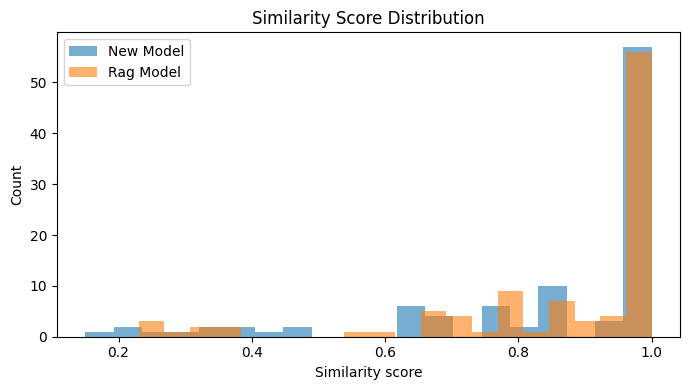

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(new2["similarity_score"], bins=20, alpha=0.6, label="New Model")
plt.hist(base2["similarity_score"], bins=20, alpha=0.6, label="Rag Model")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.legend()
plt.title("Similarity Score Distribution")
plt.tight_layout()
plt.show()

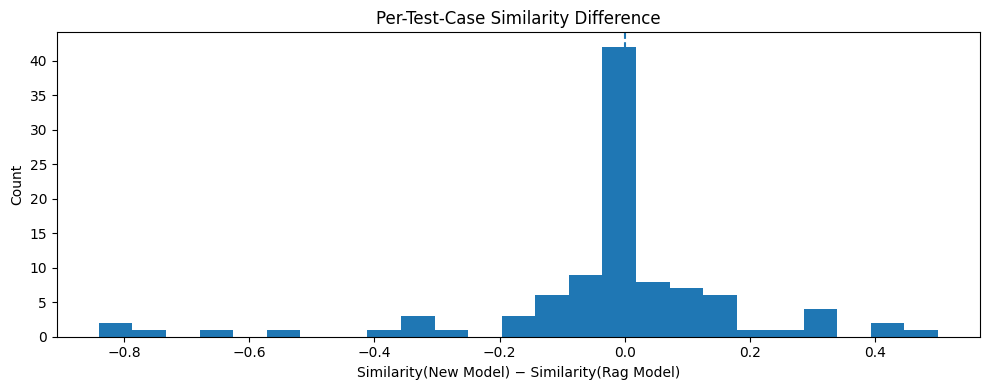

In [27]:
diff = new2["similarity_score"] - base2["similarity_score"]

plt.figure(figsize=(10,4))
plt.hist(diff, bins=25)
plt.axvline(0, linestyle="--")
plt.xlabel("Similarity(New Model) − Similarity(Rag Model)")
plt.ylabel("Count")
plt.title("Per-Test-Case Similarity Difference")
plt.tight_layout()
plt.show()

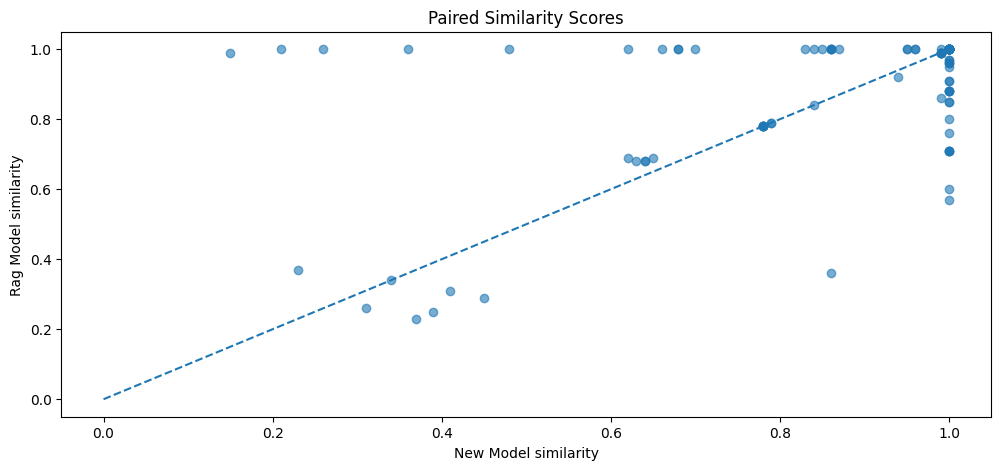

In [28]:
plt.figure(figsize=(12,5))
plt.scatter(
    x= new2["similarity_score"],
    y= base2["similarity_score"],
    alpha=0.6,
)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("New Model similarity")
plt.ylabel("Rag Model similarity")
plt.title("Paired Similarity Scores")
# plt.tight_layout()
plt.show()

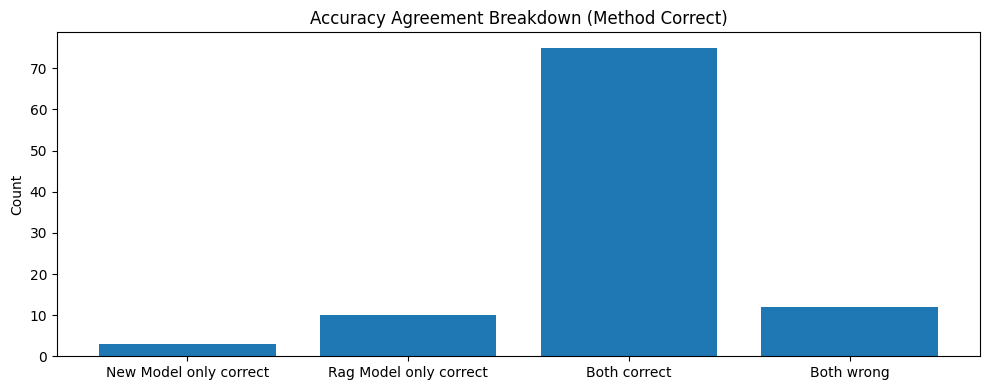

In [29]:
a_only = ((new2.method_correct) & (~base2.method_correct)).sum()
b_only = ((~new2.method_correct) & (base2.method_correct)).sum()
both = ((new2.method_correct) & (base2.method_correct)).sum()
neither = ((~new2.method_correct) & (~base2.method_correct)).sum()

plt.figure(figsize=(10,4))
plt.bar(
    ["New Model only correct", "Rag Model only correct", "Both correct", "Both wrong"],
    [a_only, b_only, both, neither]
)
plt.ylabel("Count")
plt.title("Accuracy Agreement Breakdown (Method Correct)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_68669/3988834128.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([err_new, err_base], labels=["New Model", "Rag Model"])


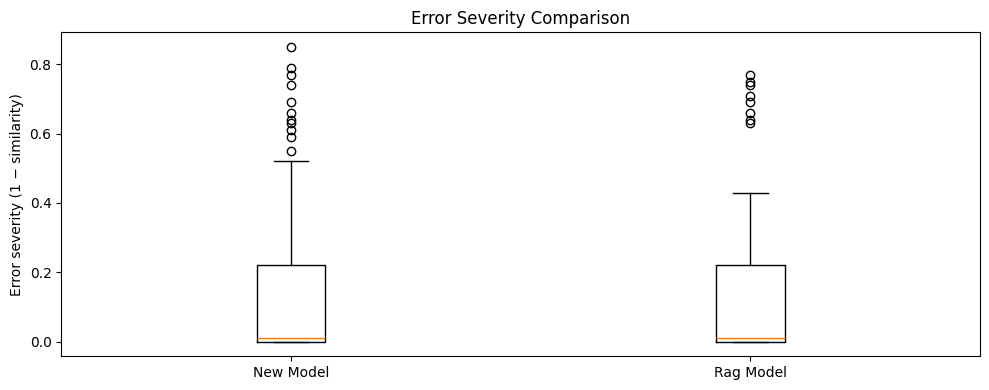

In [30]:
err_new = 1 - new2["similarity_score"]
err_base = 1 - base2["similarity_score"]

plt.figure(figsize=(10,4))
plt.boxplot([err_new, err_base], labels=["New Model", "Rag Model"])
plt.ylabel("Error severity (1 − similarity)")
plt.title("Error Severity Comparison")
plt.tight_layout()
plt.show()

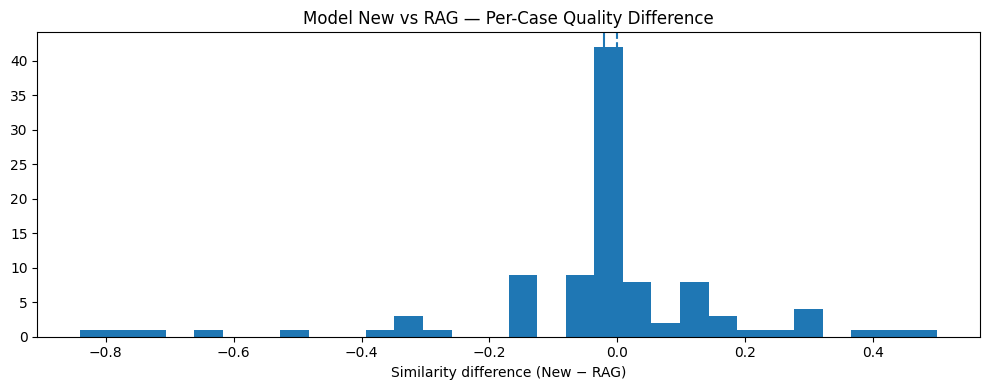

In [31]:
plt.figure(figsize=(10,4))
plt.hist(diff, bins=30)
plt.axvline(0, linestyle="--")
plt.axvline(diff.mean())
plt.title("Model New vs RAG — Per-Case Quality Difference")
plt.xlabel("Similarity difference (New − RAG)")
plt.tight_layout()
plt.show()

In [32]:
new_model["task_type"] = (
    new_model["instruction"]
    .str.lower()
    .str.extract(r'^(sort|compute|filter|extract|group|return)')
    .fillna("other")
)

rag_model["task_type"] = (
    rag_model["instruction"]
    .str.lower()
    .str.extract(r'^(sort|compute|filter|extract|group|return)')
    .fillna("other")
)

In [33]:
task_stats_new = (
    new_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
      .sort_values("accuracy")
)

task_stats_new

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
extract,0.000000,0.782500,1.000000,0.217500,8
return,0.000000,0.468125,1.000000,0.531875,16
filter,0.642857,0.870000,0.357143,0.130000,14
compute,0.676471,0.919412,0.323529,0.080588,34
other,1.000000,1.000000,0.000000,0.000000,23
sort,1.000000,0.952000,0.000000,0.048000,5


In [34]:
task_stats_base = (
rag_model.groupby("task_type")
      .agg(
          accuracy=("is_correct", "mean"),
          avg_similarity=("similarity_score", "mean"),
          error_rate=("is_correct", lambda x: 1 - x.mean()),
          avg_error_severity=("similarity_score", lambda x: (1 - x).mean()),
          count=("test_case_id", "count")
      )
      .sort_values("accuracy")
)

task_stats_base

,accuracy,avg_similarity,error_rate,avg_error_severity,count
task_type,,,,,
extract,0.000000,0.782500,1.000000,0.217500,8
filter,0.500000,0.849286,0.500000,0.150714,14
return,0.500000,0.650625,0.500000,0.349375,16
compute,0.647059,0.922059,0.352941,0.077941,34
other,0.913043,0.964783,0.086957,0.035217,23
sort,1.000000,0.984000,0.000000,0.016000,5


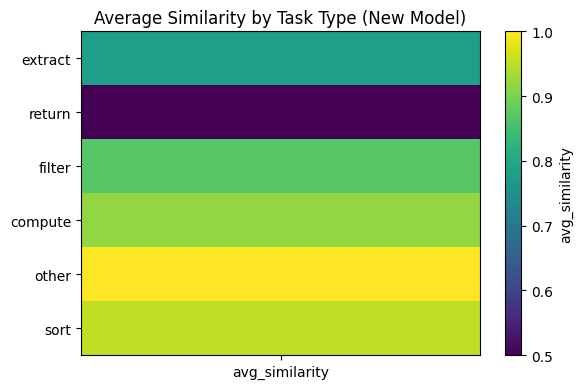

In [35]:
plt.figure(figsize=(6,4))
plt.imshow(
    task_stats_new[["avg_similarity"]].values,
    aspect="auto",
    vmin=0.5,
    vmax=1.0
)
plt.xticks([0], ["avg_similarity"])
plt.yticks(range(len(task_stats_new)), task_stats_new.index)
plt.colorbar(label="avg_similarity")
plt.title("Average Similarity by Task Type (New Model)")
plt.tight_layout()
plt.show()

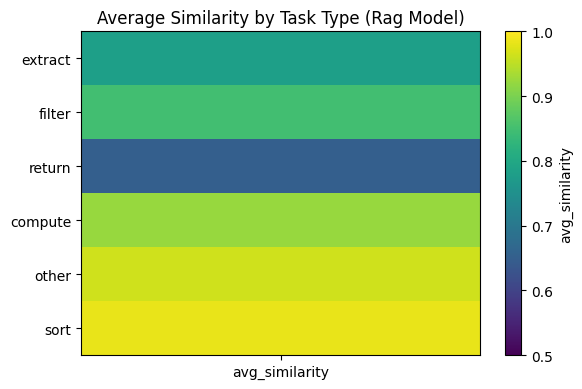

In [36]:
plt.figure(figsize=(6,4))
plt.imshow(
    task_stats_base[["avg_similarity"]].values,
    aspect="auto",
    vmin=0.5,
    vmax=1.0
)
plt.xticks([0], ["avg_similarity"])
plt.yticks(range(len(task_stats_base)), task_stats_base.index)
plt.colorbar(label="avg_similarity")
plt.title("Average Similarity by Task Type (Rag Model)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_68669/295813842.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  new_model.pivot_table(


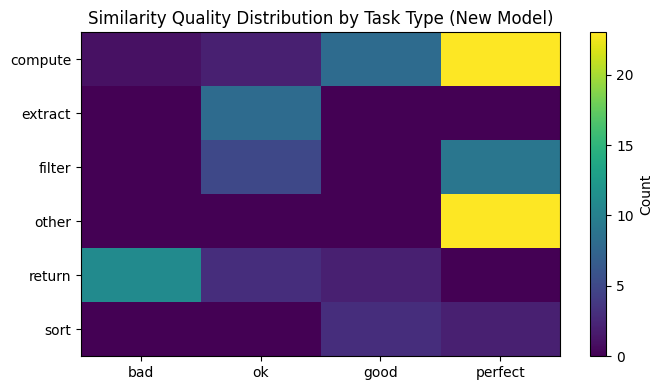

In [37]:
new_model["sim_bin"] = pd.cut(
    new_model["similarity_score"],
    bins=[0, 0.6, 0.8, 0.95, 1.0],
    labels=["bad", "ok", "good", "perfect"]
)

pivot = (
    new_model.pivot_table(
        index="task_type",
        columns="sim_bin",
        values="test_case_id",
        aggfunc="count",
        fill_value=0
    )
)

plt.figure(figsize=(7,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Count")
plt.title("Similarity Quality Distribution by Task Type (New Model)")
plt.tight_layout()
plt.show()

/var/folders/tt/5g7kjc2j66b3f51x1pj2tcqh0000gn/T/ipykernel_68669/2442032237.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rag_model.pivot_table(


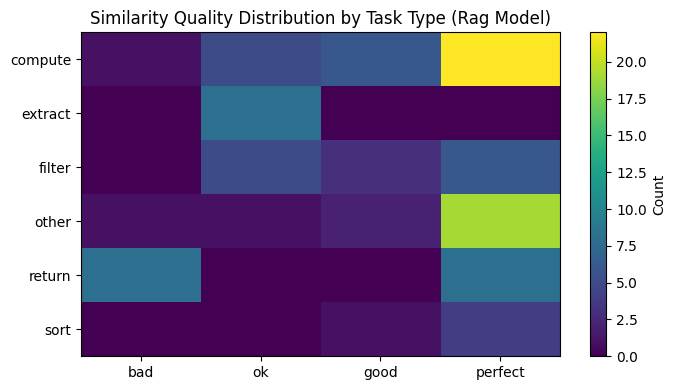

In [38]:
rag_model["sim_bin"] = pd.cut(
    rag_model["similarity_score"],
    bins=[0, 0.6, 0.8, 0.95, 1.0],
    labels=["bad", "ok", "good", "perfect"]
)

pivot = (
    rag_model.pivot_table(
        index="task_type",
        columns="sim_bin",
        values="test_case_id",
        aggfunc="count",
        fill_value=0
    )
)

plt.figure(figsize=(7,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Count")
plt.title("Similarity Quality Distribution by Task Type (Rag Model)")
plt.tight_layout()
plt.show()

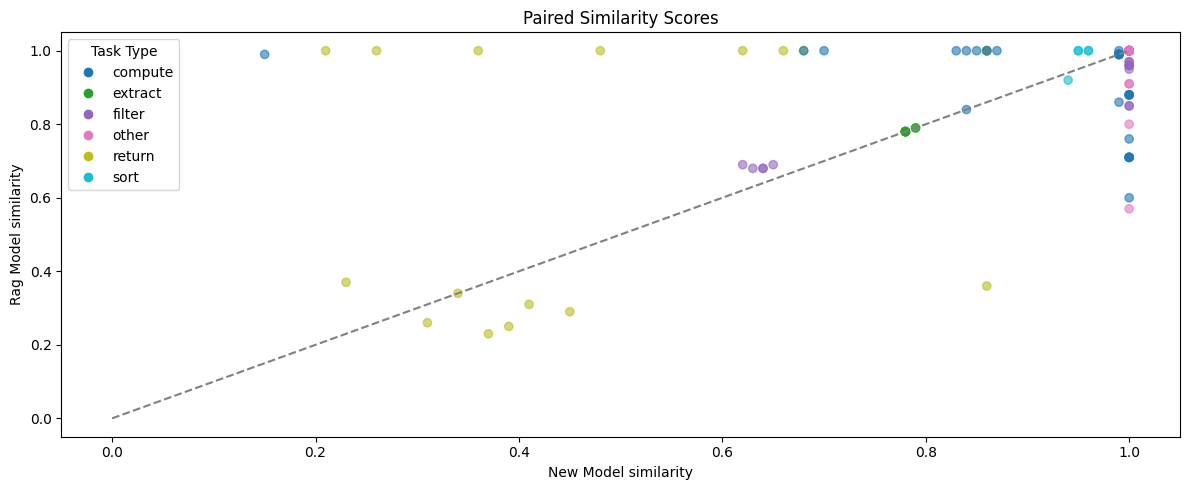

In [39]:
new_model2 = new_model.sort_values('test_case_id').reset_index(drop=True)
base_model2 = rag_model.sort_values('test_case_id').reset_index(drop=True)
plt.figure(figsize=(12,5))

# Encode task_type as categories
cats = new_model2['task_type'].astype('category')
codes = cats.cat.codes
labels = cats.cat.categories

# Scatter
scatter = plt.scatter(
    x=new_model2["similarity_score"],
    y=base_model2["similarity_score"],
    c=codes,
    alpha=0.6,
    cmap="tab10"
)

# Identity line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Build legend manually
handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=scatter.cmap(scatter.norm(i)),
        label=label
    )
    for i, label in enumerate(labels)
]

plt.legend(handles=handles, title="Task Type")

plt.xlabel("New Model similarity")
plt.ylabel("Rag Model similarity")
plt.title("Paired Similarity Scores")

plt.tight_layout()
plt.show()

In [40]:
rag_model[rag_model["task_type"] == "return"]

,test_case_id,instruction,expected_output,generated_output,similarity_score,is_correct,method_correct,error,task_type,sim_bin
36,37,Return top 172 rows by price_rt.,"df.nlargest(172, 'price_rt')","df.nlargest(172, 'price_rt')",1.00,True,True,NaN,return,perfect
39,40,Return bottom 51 rows by price_da.,"df.nsmallest(51, 'price_da')","df.nsmallest(51, 'price_da')",1.00,True,True,NaN,return,perfect
40,41,Return top 48 rows by solar_fcst_scaled.,"df.nlargest(48, 'solar_fcst_scaled')","df.nlargest(48, 'solar_fcst_scaled')",1.00,True,True,NaN,return,perfect
64,65,Return bottom 139 rows by total.,"df.nsmallest(139, 'total')","df.nsmallest(139, 'total')",1.00,True,True,NaN,return,perfect
69,70,Return top 67 rows by day_ahead_forecast.,"df.nlargest(67, 'day_ahead_forecast')","df.nlargest(67, 'day_ahead_forecast')",1.00,True,True,NaN,return,perfect
73,74,Return top 12 rows by price_rt.,"df.nlargest(12, 'price_rt')","df.nlargest(12, 'price_rt')",1.00,True,True,NaN,return,perfect
11,12,Return top 49 rows by predicted_delta.,"df.nlargest(49, 'predicted_delta')","df.nlargest(49, 'predicted_delta')",1.00,True,True,NaN,return,perfect
16,17,Return top 94 rows by total_raw.,"df.nlargest(94, 'total_raw')","df.nlargest(94, 'total_raw')",1.00,True,True,NaN,return,perfect
56,57,Return top 29 rows by wind_fcst_raw.,"df.nlargest(29, 'wind_fcst_raw')",df.head(29),0.37,False,False,NaN,return,bad
15,16,Return bottom 130 rows by total.,"df.nsmallest(130, 'total')",df.iloc[:130],0.36,False,False,NaN,return,bad
